# ROC Curve

Conda environment for this notebook is in `development/plots/environment.yml`

Based on [HLS4ML tutorial plotting.py](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/plotting.py)


In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotting

# standardize colors
from cycler import cycler 
colors = [ "#3e6990", "#aabd8c", "#8a8565", "#f39b6d","#381d2a",]
plt.rcParams['axes.prop_cycle'] = cycler('color', colors)

# Fonts match with latex
matplotlib.rcParams.update({
    'font.family': 'serif',
})

Overlapping comparison of baseline and quantized and ondboard verification

In [2]:
prediction_dir = 'predictions/'

y_true = np.load("y_test.npy")
y_baseline = np.load("y_baseline.npy") # generated from baseline keras model
classes = np.load("classes.npy", allow_pickle=True)

In [5]:
def dut_roc(y_dut, plotname):
    fig, ax = plt.subplots(figsize=(10, 6))
    _ = plotting.makeRoc(y_true, y_baseline, classes, linestyle="-")
    plt.gca().set_prop_cycle(None)  # reset the colors
    _ = plotting.makeRoc(y_true, y_dut, classes, linestyle="--")
    plt.gca().set_prop_cycle(None)  # reset the colors
    #ax.set_title("Logarithmic x-axis", size='x-large')

    plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
    plt.tight_layout()
    plt.show()

    fig.savefig(f"export/{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")

Searching for predictions in predictions/


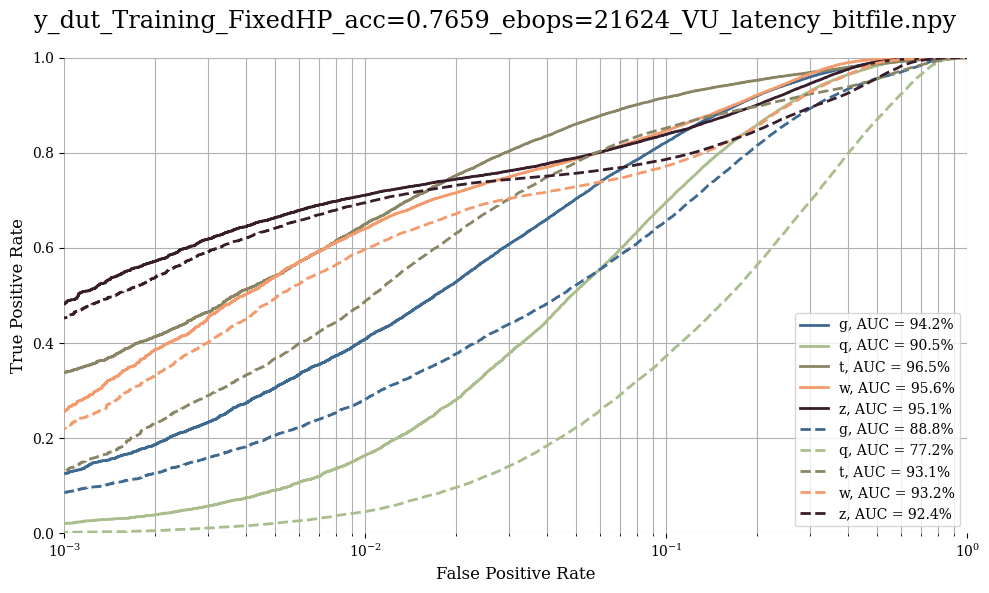

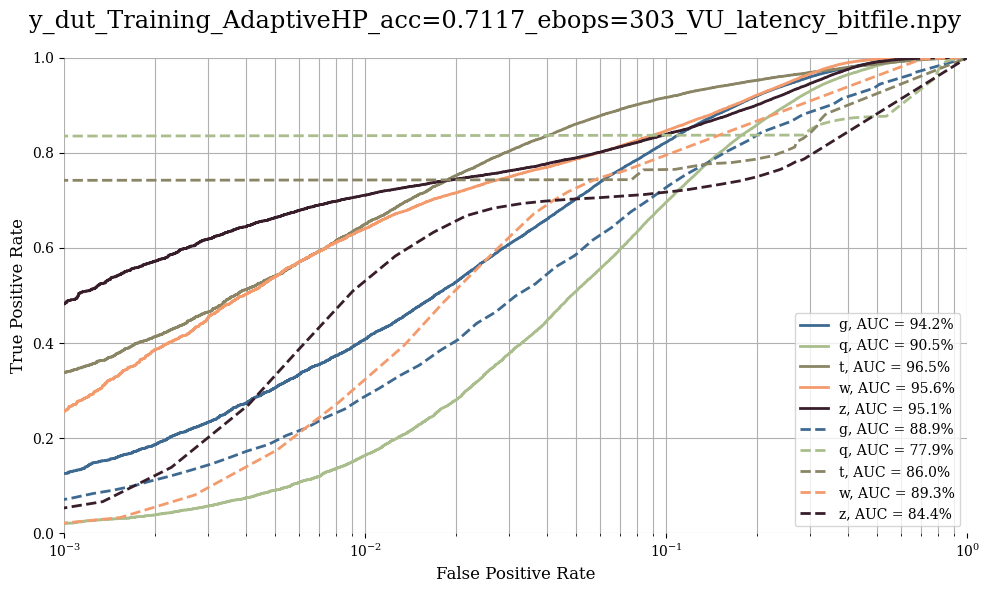

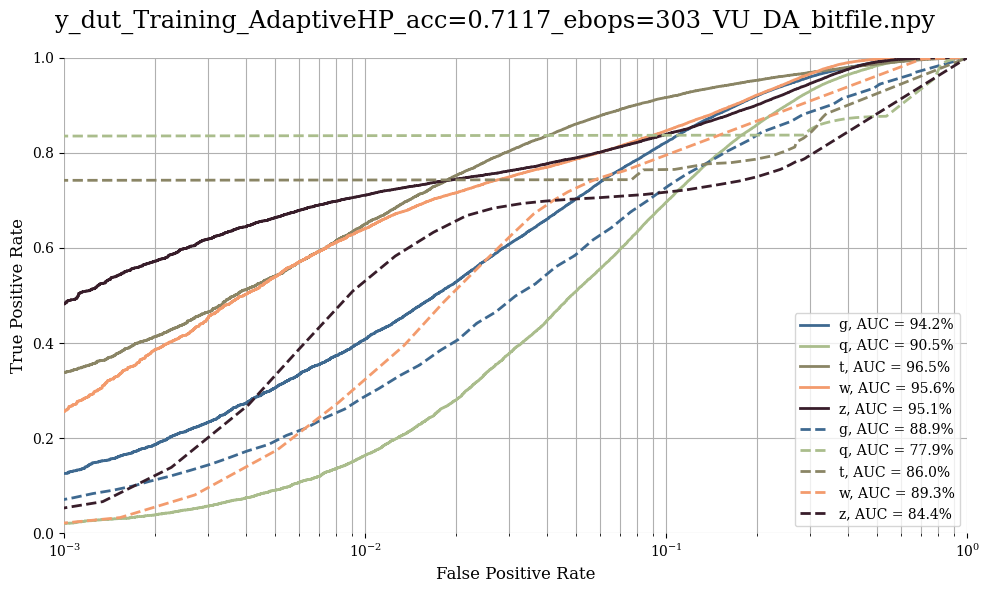

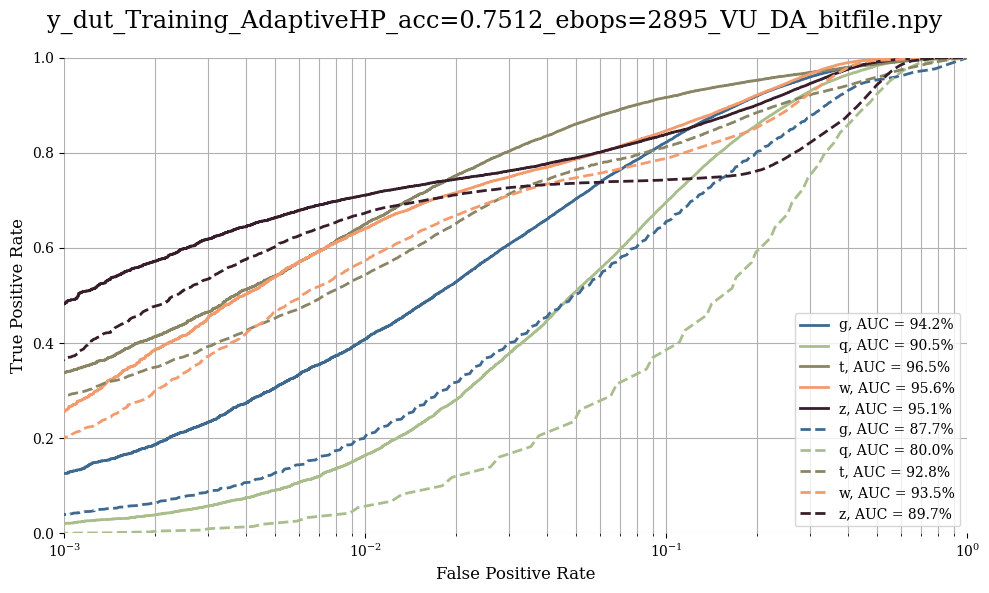

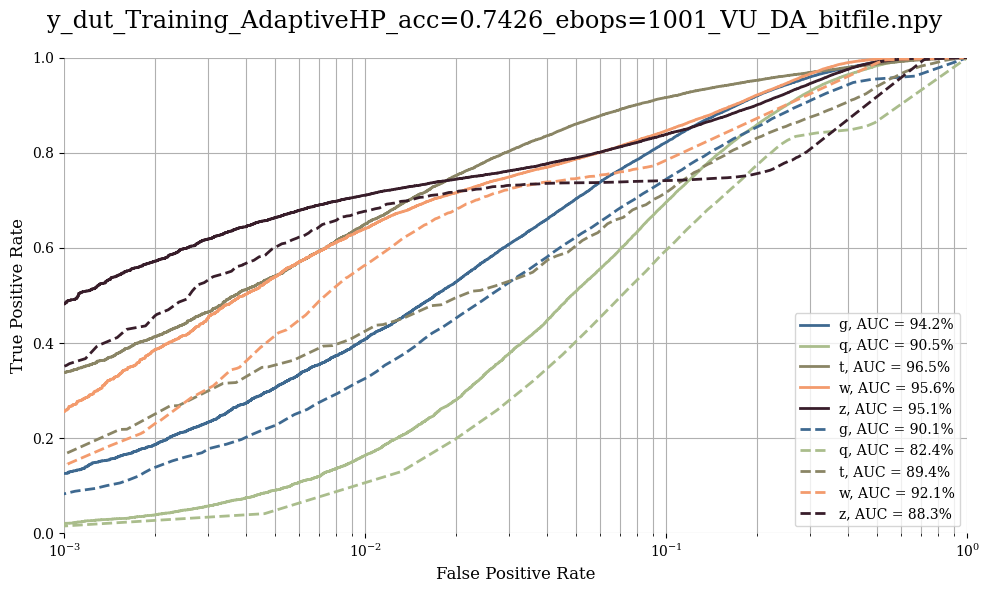

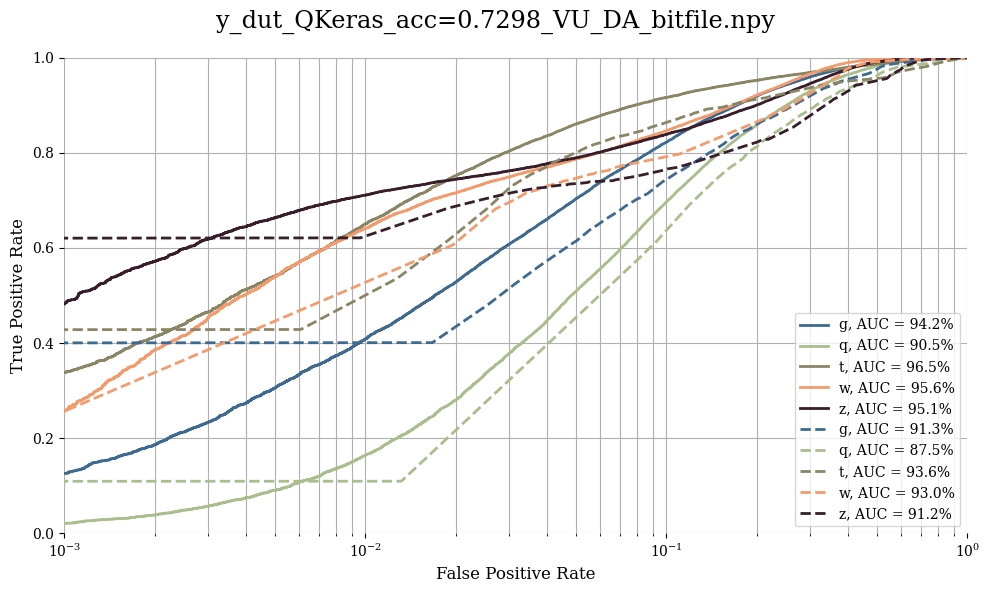

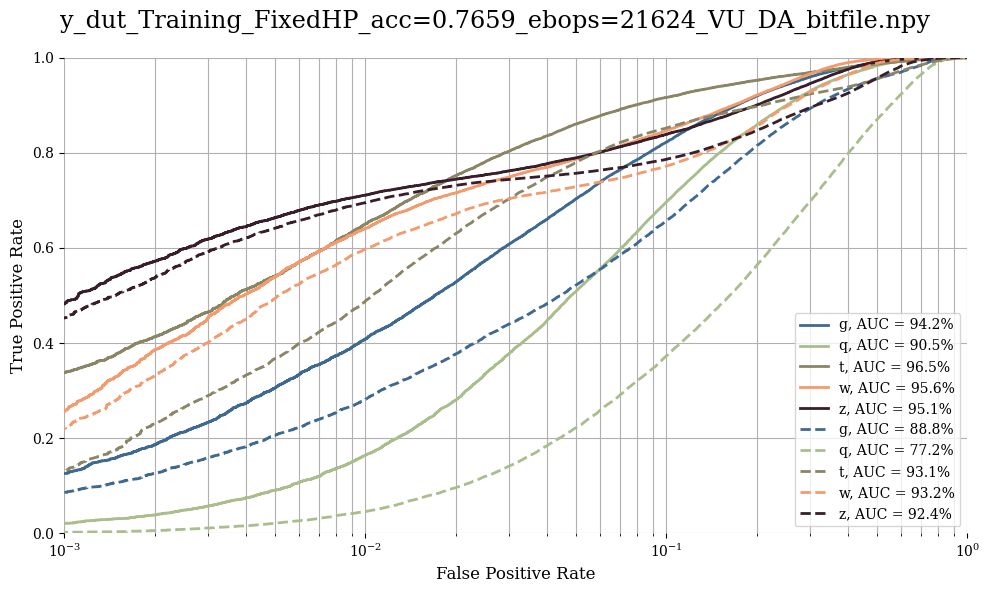

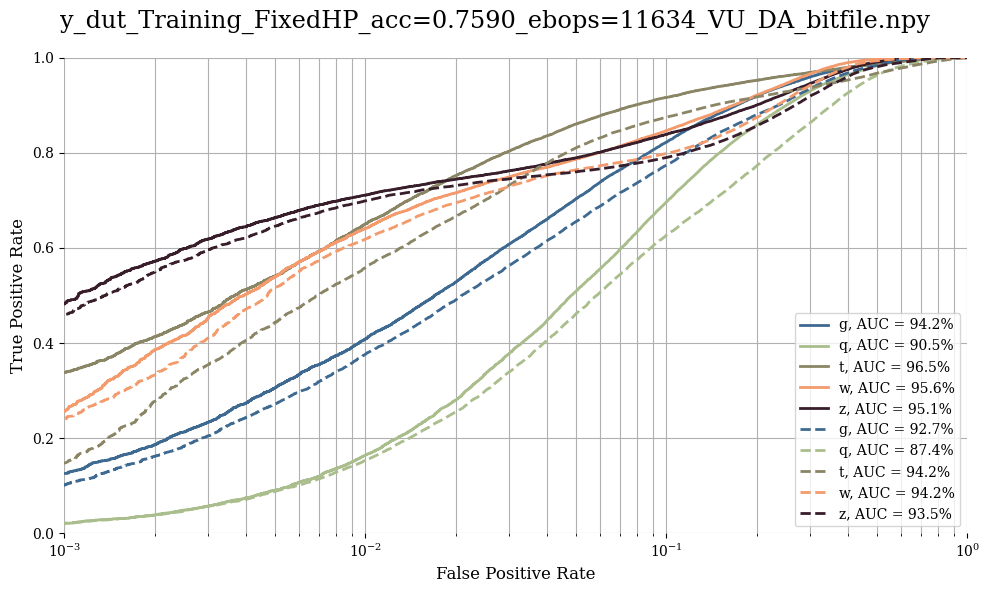

In [6]:
from pathlib import Path

print(f"Searching for predictions in {prediction_dir}")
for prediction_path in Path(prediction_dir).rglob('*.npy'):
    y_dut = np.load(prediction_path)
    dut_roc(y_dut, str(prediction_path.name))
